# 1. Project Overview

## Problem Statement

In this project, we have historical gym attendance data, and our goal is to use the available information about each visit — such as the **day, time, and other relevant features** — to predict the number of people present in the gym.

In other words, we want to answer the following question:

> **Given the information available about a specific gym session, how many people are expected to be in the gym?**

This is a prediction problem because we are using historical data to learn patterns that can help us make predictions about new observations.

---

## Objective

The main objective of this project is to build a **Machine Learning model** that can predict gym attendance.

Our model will learn the relationship between the available input variables and the number of people attending the gym.

### Target Variable

The **Target / Dependent Variable (`y`)** is:

> **The number of people in the gym**

This is the value that we want our model to predict.

### Features

The **Features / Independent Variables (`X`)** are the available pieces of information that we can use to make the prediction.

For example, depending on the dataset, these may include:

* Day of the week
* Time of day
* Date
* Other available gym-related information

The features are used as the input to the Machine Learning model.

---

## What Type of Machine Learning Problem Is This?

This project is an example of:

**Supervised Learning → Regression**

### Why Supervised Learning?

We have historical observations where both the **input features (`X`)** and the actual attendance (`y`) are known.

The model will learn from these examples:

```text
Features (X)  →  Model  →  Attendance (y)
```

After learning from the historical data, the model can use new feature values to predict the expected attendance.

### Why Regression?

The target variable is a **numeric value** representing the number of people in the gym.

We are not predicting a category such as:

```text
Busy / Not Busy
```

Instead, we are predicting a numerical value such as:

```text
25 people
42 people
67 people
```

Therefore, this is a **Regression problem**.

---

## Machine Learning Approach

For this project, we will use **Linear Regression**.

The basic idea of Linear Regression is to find a mathematical relationship between the input features and the target variable.

In a simple form, the model can be represented as:

$$
\hat{y} = w_1x_1 + w_2x_2 + \dots + w_nx_n + b
$$

Where:

* $\hat{y}$ = predicted gym attendance
* $x_1, x_2, \dots, x_n$ = input features
* $w_1, w_2, \dots, w_n$ = model weights / parameters
* $b$ = bias / intercept

The model learns the values of the **weights** and **bias** from the training data.

---

## Optimization Method

To train the Linear Regression model, we will use **Stochastic Gradient Descent (SGD)**.

Instead of calculating the model parameters directly, Gradient Descent iteratively updates the model parameters in order to reduce the prediction error.

With **Stochastic Gradient Descent**, the model updates its parameters using individual training examples or small batches of data rather than using the entire dataset at every update.

In this project, we will implement this approach using:

```python
SGDRegressor
```

from `scikit-learn`.

---

## Project Workflow

The complete project will follow this workflow:

**Problem → Data → Preparation → Model → Training → Evaluation → Visualization → Conclusion**

More specifically:

1. **Understand the problem**
2. **Load the dataset**
3. **Explore the data**
4. **Clean the data**
5. **Prepare the features and target**
6. **Split the data into training and testing sets**
7. **Build the Linear Regression model**
8. **Train the model using Stochastic Gradient Descent**
9. **Evaluate the model**
10. **Visualize the predictions**
11. **Interpret the results**
12. **Draw a final conclusion**

The goal is not only to build a model, but also to understand **why we are doing each step and how each step contributes to the final prediction.**


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv(r'E:\project_DS\Stochastic GD on LR\data.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [5]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [6]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


In [9]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(62184, 11)
Index(['number_people', 'date', 'timestamp', 'day_of_week', 'is_weekend',
       'is_holiday', 'temperature', 'is_start_of_semester',
       'is_during_semester', 'month', 'hour'],
      dtype='object')
number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64


In [10]:
df.duplicated().sum()

0

In [11]:
(df["number_people"] == 0).sum()

8775

In [12]:
df["number_people"].value_counts().sort_index()


number_people
0      8775
1      3029
2      1143
3       585
4       407
       ... 
125       1
134       1
138       1
139       1
145       1
Name: count, Length: 128, dtype: int64

In [13]:
df.corr(numeric_only=True)["number_people"].sort_values()

is_weekend             -0.173958
day_of_week            -0.162062
month                  -0.097854
is_holiday             -0.048249
is_start_of_semester    0.182683
is_during_semester      0.335350
temperature             0.373327
timestamp               0.550218
hour                    0.552049
number_people           1.000000
Name: number_people, dtype: float64

In [14]:
df.groupby("hour")["number_people"].mean()

hour
0     14.720282
1      2.404040
2      0.178289
3      0.145023
4      0.279054
5      1.045063
6      8.763234
7     15.393049
8     24.054325
9     30.190068
10    33.733906
11    36.219635
12    36.110517
13    34.572902
14    33.931109
15    37.197624
16    42.959402
17    47.637582
18    48.297850
19    44.741043
20    41.669767
21    42.922634
22    40.463784
23    26.147038
Name: number_people, dtype: float64

In [15]:
df.groupby("day_of_week")["number_people"].mean()

day_of_week
0    32.653315
1    32.435926
2    32.441376
3    30.217455
4    29.957105
5    22.956699
6    22.618613
Name: number_people, dtype: float64

In [16]:
df.groupby("is_weekend")["number_people"].mean()

is_weekend
0    31.551397
1    22.788175
Name: number_people, dtype: float64

In [17]:
df.groupby("is_holiday")["number_people"].mean()

is_holiday
0    29.128144
1     7.518750
Name: number_people, dtype: float64

In [18]:
df.groupby("is_during_semester")["number_people"].mean()

is_during_semester
0    18.466468
1    34.530971
Name: number_people, dtype: float64

In [19]:
df.groupby("is_start_of_semester")["number_people"].mean()

is_start_of_semester
0    27.860026
1    43.241330
Name: number_people, dtype: float64

In [20]:
df.groupby("month")["number_people"].mean()

month
1     33.459713
2     39.218846
3     33.249019
4     38.538406
5     19.837116
6     20.309137
7     20.730380
8     26.744129
9     38.817038
10    33.761564
11    28.806892
12    19.319781
Name: number_people, dtype: float64

# Preprocessing

We haven't done any real visualization yet.

The correlation showed us that:

```text
temperature ↔ number_people = 0.373
```

But this number alone is not enough.

We want to **see the relationship**:

* Does the number of people actually increase when the temperature increases?
* Or does the relationship have a different shape?

This will be our first step from:

**Numerical EDA → Visualization EDA**

There may be a **nonlinear relationship** between temperature and gym attendance, but the correlation value alone cannot tell us the exact shape of this relationship.


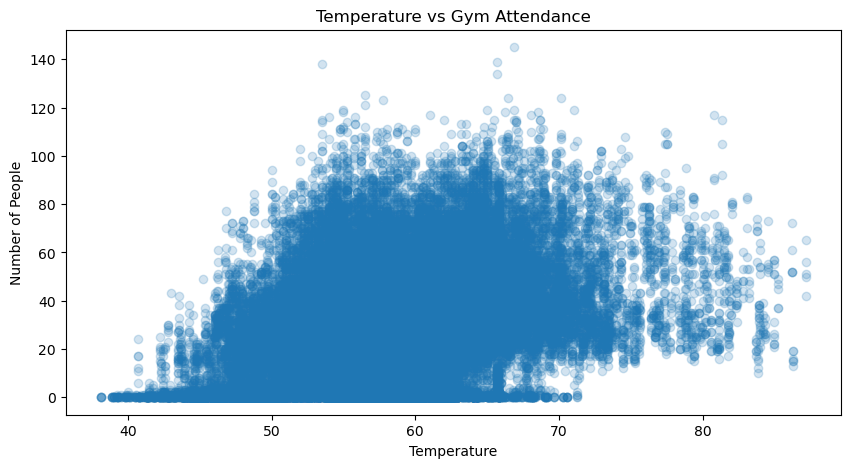

In [22]:

plt.figure(figsize=(10, 5))
plt.scatter(df["temperature"], df["number_people"], alpha=0.2)
plt.xlabel("Temperature")
plt.ylabel("Number of People")
plt.title("Temperature vs Gym Attendance")
plt.show()

### Feature Selection

The target variable is `number_people`, which represents the number of people at the gym.

The remaining relevant variables are used as features to help the model learn patterns in gym attendance.

Each feature provides different information that may affect the number of people at the gym:

* `timestamp`: Provides the exact date and time, which can help capture attendance patterns throughout the day and across different dates.
* `temperature`: Helps the model understand whether temperature affects gym attendance.
* `day_of_week`: Captures differences in attendance between weekdays.
* `is_weekend`: Helps identify different attendance patterns on weekends.
* `is_holiday`: Captures changes in attendance during holidays.
* `is_start_of_semester`: Helps identify attendance patterns at the beginning of a semester.
* `is_during_semester`: Indicates whether the gym is operating during the semester, which may affect attendance.
* `month`: Captures seasonal patterns that may affect gym attendance.

`hour` is excluded because `timestamp` already contains the time of day with greater precision. Including both would provide redundant information.

The selected features are:

```text
timestamp
temperature
day_of_week
is_weekend
is_holiday
is_start_of_semester
is_during_semester
month
```

The model will use these features to learn patterns and predict `number_people`.


In [23]:
features = [
    "timestamp",
    "temperature",
    "day_of_week",
    "is_weekend",
    "is_holiday",
    "is_during_semester",
    "is_start_of_semester",
    "month"
]

x = df[features]
y = df["number_people"]

### Train-Test Split

We split the dataset into two parts: **training data** and **testing data**.

The **training data** is used to train the model and learn the patterns and relationships between the features and the target variable.

The **testing data** is kept **unseen during training**. After the model is trained, we use the testing data to evaluate how well it performs on new data.

This helps us check whether the model has learned useful patterns or simply memorized the training data.

By using a separate test set, we can get a better idea of how well the model will **generalize to unseen data**.


In [ ]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Splitting the Dataset

We split the dataset into **training** and **testing** sets.

* **80%** of the data is used to train the model and learn the patterns in the data.
* **20%** of the data is kept for testing and evaluating the model on unseen data.

We use `random_state=42` to make the split **reproducible**, which means we will get the same training and testing sets every time we run the code.

This allows us to evaluate the model fairly and consistently.


In [28]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(49747, 8)
(12437, 8)
(49747,)
(12437,)


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(x_train_scaled.shape)
print(x_test_scaled.shape)

(49747, 8)
(12437, 8)


### Feature Scaling

The features have different ranges and scales. For example, `temperature` has a different range compared to `month` or `day_of_week`.

To make the features comparable, we use `StandardScaler` to standardize the training and testing features.

The scaler is **fitted only on the training data** to avoid **data leakage**. After that, the same transformation is applied to the test data.

This ensures that the test data remains completely unseen during the training process.

### Building the Model

We use `SGDRegressor` to build a **linear regression model** using **Stochastic Gradient Descent (SGD)**.

The model learns a coefficient for each feature and uses these coefficients to make predictions for `number_people`.

During training, the model updates its coefficients step by step to reduce the **prediction error** on the training data.

After training, we can use the learned model to predict gym attendance for new, unseen data.


In [31]:
from sklearn.linear_model import SGDRegressor

model = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

model.fit(x_train_scaled, y_train)

SGDRegressor(random_state=42)

In [32]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [29.29533178]
Coefficients: [11.31418518  5.60778953 -1.73812841 -2.64197007 -0.58882217  5.8288345
  1.94612761 -2.7497687 ]


### Model Coefficients

The coefficients are in the same order as the features we selected.

Each coefficient shows how the corresponding feature affects the model's prediction of `number_people`.

* A **positive coefficient** means that an increase in the feature is associated with an increase in the predicted number of people.
* A **negative coefficient** means that an increase in the feature is associated with a decrease in the predicted number of people.
* The larger the absolute value of the coefficient, the stronger its effect on the prediction, assuming the features are on the same standardized scale.

| Feature                | Coefficient |
| ---------------------- | ----------: |
| `timestamp`            |  **+11.31** |
| `temperature`          |   **+5.61** |
| `day_of_week`          |   **-1.74** |
| `is_weekend`           |   **-2.64** |
| `is_holiday`           |   **-0.59** |
| `is_start_of_semester` |   **+5.83** |
| `is_during_semester`   |   **+1.95** |
| `month`                |   **-2.75** |
| `Intercept`                |   **29.30** |

In [33]:
y_pred = model.predict(x_test_scaled)


print(y_pred[:10])
print(y_test.head(10).values)

[20.29872029 35.52605335 29.68677679 73.29642803  7.16737316 70.75136791
  6.92257288 56.44425378 13.82842354 47.88405515]
[ 1 27 26 71  0 79 18 58 34 64]


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

MAE: 12.118865341767457
MSE: 251.80848568857488
R²: 0.512799445664706


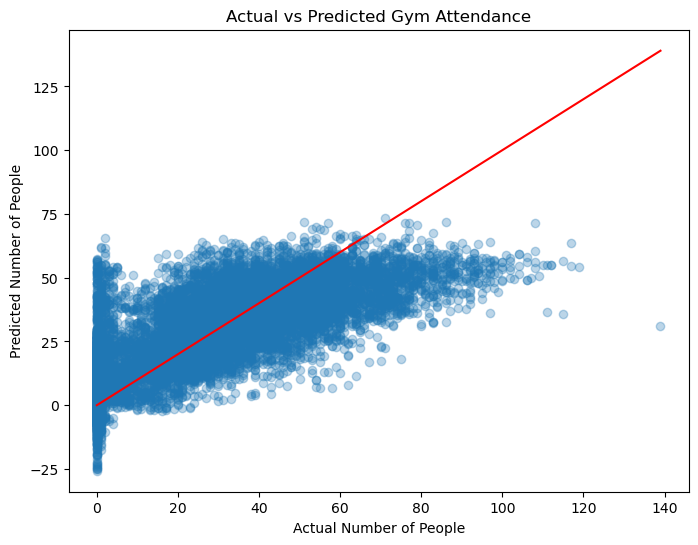

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Number of People")
plt.ylabel("Predicted Number of People")
plt.title("Actual vs Predicted Gym Attendance")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

### Model Improvement — Random Forest

After building the baseline **Linear Regression model** using **Stochastic Gradient Descent (SGD)**, we noticed that the relationship between gym attendance and the features is not completely linear.

The **Actual vs Predicted** plot also showed noticeable prediction errors, especially when the number of people was high.

To improve the model, we will use a **Random Forest Regressor**.

Random Forest can capture **nonlinear relationships** and **interactions between features**, which makes it a good choice for this dataset.

We will then compare the Random Forest model with the baseline SGD Linear Regression model using the following evaluation metrics:

* **MAE (Mean Absolute Error)**
* **MSE (Mean Squared Error)**
* **RMSE (Root Mean Squared Error)**
* **R² (R-squared)**

This comparison will help us determine whether the Random Forest model provides better predictions than the baseline model.


In [38]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)


### Random Forest Regressor

**Random Forest** is a tree-based ensemble model that can capture **nonlinear relationships** and **interactions between features**.

Unlike **SGD Linear Regression**, Random Forest does not require feature scaling. This is because it makes predictions using **decision-tree splits** rather than distance-based or gradient-based calculations.

A Random Forest consists of multiple **Decision Trees**. Each tree makes its own prediction based on the input features.

For regression, the final prediction is calculated by taking the **average of the predictions from all the trees**.

For example:

```text
Tree 1 → 120 people
Tree 2 → 130 people
Tree 3 → 125 people
Tree 4 → 135 people

Final Prediction → 127.5 people
```

We will train the Random Forest model using the **same training data** and evaluate it on the **same test data**.

Using the same data for both models allows us to make a **fair comparison** between Random Forest and the baseline SGD Linear Regression model.


In [40]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 4.362727250740558
Random Forest MSE: 42.93003033068356
Random Forest RMSE: 6.552101214929723
Random Forest R²: 0.9169387222295304


### Model Comparison

The **Random Forest Regressor** significantly outperformed the **SGD Linear Regression** model on the test data.

| Metric   | SGD Linear Regression | Random Forest |
| -------- | --------------------: | ------------: |
| **MAE**  |                 12.12 |      **4.36** |
| **RMSE** |                 15.87 |      **6.55** |
| **R²**   |                 0.513 |     **0.917** |

The **MAE** decreased from **12.12 to 4.36**, which means that the Random Forest predictions are much closer to the actual number of people on average.

The **RMSE** also decreased from **15.87 to 6.55**, showing a significant reduction in prediction errors, especially larger errors.

The **R² score** increased from **0.513 to 0.917**. This means that the Random Forest model explains much more of the variation in gym attendance on the test data.

Overall, the results show that **Random Forest is much better suited for this dataset** than the linear regression model.

This improvement suggests that gym attendance has **nonlinear relationships and interactions between features** that the linear regression model could not capture effectively.


In [42]:
rf_train_pred = rf_model.predict(x_train)

rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_train_r2 = r2_score(y_train, rf_train_pred)

print("Training MAE:", rf_train_mae)
print("Training R²:", rf_train_r2)

Training MAE: 1.6234845508750468
Training R²: 0.9880889313189243


### Checking for Overfitting

To check for **overfitting**, we compared the Random Forest performance on the training and testing datasets.

The model achieved:

* **Training R²:** 0.988
* **Testing R²:** 0.917

The higher R² on the training data means that the model fits the training data very closely.

Since the test R² is lower than the training R², there is **some evidence of overfitting**. However, the test R² is still high, which means that the model performs well on unseen data and generalizes much better than the baseline **SGD Linear Regression** model.

To see if we can reduce overfitting while keeping good test performance, we can control the complexity of the Random Forest using parameters such as `max_depth`.

This allows us to find a better balance between **fitting the training data** and **generalizing to new data**.


In [43]:
depths = [5, 10, 15, 20]

results = []

for depth in depths:
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(x_train, y_train)
    
    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)
    
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    
    results.append([
        depth,
        train_mae,
        test_mae,
        train_r2,
        test_r2
    ])

In [44]:
results_df = pd.DataFrame(
    results,
    columns=[
        "max_depth",
        "train_mae",
        "test_mae",
        "train_r2",
        "test_r2"
    ]
)

results_df

,max_depth,train_mae,test_mae,train_r2,test_r2
0,5,9.348873,9.324060,0.648948,0.651499
1,10,7.074775,7.316289,0.780356,0.769061
2,15,4.626984,5.728771,0.893380,0.852539
3,20,2.549715,4.667637,0.967554,0.904898


### Hyperparameter Tuning

We tested different values of `max_depth` to understand how the **tree depth** affects the Random Forest model's performance.

Smaller values of `max_depth` caused **underfitting**, because the trees were too simple to capture the important patterns in the data.

As we increased the tree depth, the model was able to capture more complex patterns, which improved its performance on the test set.

Among the tested values, `max_depth=20` achieved the **best test performance**.

However, the original Random Forest model without a `max_depth` restriction performed even better, with a higher **R²** and a lower **MAE** on the test set.

Therefore, based on our experiments, the **original Random Forest remains the best-performing model**.


In [45]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5]
}

In [46]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

### Cross-Validation and Hyperparameter Tuning

Instead of using the **test set** to choose the best hyperparameters, we use **5-fold cross-validation** on the training data.

This means that the training data is divided into 5 parts. The model is trained on 4 parts and validated on the remaining part. This process is repeated 5 times, so each part is used for validation once.

This helps us choose the best model configuration while keeping the **test set completely unseen**.

We use `GridSearchCV` to test different combinations of:

* `n_estimators`
* `max_depth`
* `min_samples_split`

For each combination, the model is evaluated using cross-validation.

We select the configuration that achieves the **lowest cross-validated MAE**, since a lower MAE means that the model's predictions are closer to the actual values.

Finally, we evaluate the selected model on the **test set** to measure its performance on completely unseen data.


In [48]:
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 15, 20, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_absolute_error')

In [49]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [50]:
print("Best CV MAE:")
print(-grid_search.best_score_)

Best CV MAE:
4.628598950928078


In [51]:
grid_search.best_estimator_

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [53]:
best_rf = grid_search.best_estimator_
final_pred = best_rf.predict(x_test)

In [54]:
final_mae = mean_absolute_error(y_test, final_pred)
final_mse = mean_squared_error(y_test, final_pred)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_pred)

print("Final MAE:", final_mae)
print("Final MSE:", final_mse)
print("Final RMSE:", final_rmse)
print("Final R²:", final_r2)

Final MAE: 4.354230732255648
Final MSE: 42.76441482069755
Final RMSE: 6.539450651293085
Final R²: 0.917259156102325


## Final Results and Conclusion

We started with a **Stochastic Gradient Descent (SGD) Linear Regression** model as our baseline.

The model achieved:

* **MAE:** 12.12
* **R²:** 0.513

on the test set.

We then trained a **Random Forest Regressor**, which significantly improved the results:

* **MAE:** 4.36
* **R²:** 0.917

This showed that Random Forest was much better at capturing the patterns in the data.

To further improve the model and avoid using the test set for hyperparameter selection, we used **5-fold cross-validation** with `GridSearchCV`.

The best configuration was:

* **`n_estimators = 200`** → 200 trees
* **`max_depth = None`** → no maximum depth restriction
* **`min_samples_split = 2`** → at least 2 samples are required to split a node

The final tuned Random Forest achieved:

* **MAE:** 4.35
* **RMSE:** 6.54
* **R²:** 0.917

on the previously unseen test set.

Overall, the **Random Forest model significantly outperformed the SGD Linear Regression baseline**.

This suggests that gym attendance is influenced by **nonlinear relationships and interactions between the features**, which the linear regression model could not capture effectively.

Therefore, the **tuned Random Forest is our best-performing model** for predicting gym attendance.
